In [1]:
# SECTION 1
# Import pandas for working with tables of data
import pandas as pd

# Import numpy for numeric arrays and math
import numpy as np

# Import matplotlib for drawing charts
import matplotlib.pyplot as plt

# Import seaborn for statistical charts built on matplotlib
import seaborn as sns

# Load the Titanic dataset from the data folder into a DataFrame
df = pd.read_csv("data/titanic.csv")

# Show the number of rows and columns
print("Shape of dataset :", df.shape)

# Show the first five rows
print("\nFirst five rows:")
print(df.head())

# Show column names, data types, and non-null counts
print("\nColumn information:")
df.info()

# Count missing values in each column
print("\nMissing values per column:")
print(df.isnull().sum())

# Count fully duplicated rows
print("\nDuplicate rows :", df.duplicated().sum())

# Count how many passengers survived (1) and did not survive (0)
print("\nSurvived counts:")
print(df["Survived"].value_counts())

Shape of dataset : (891, 12)

First five rows:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0

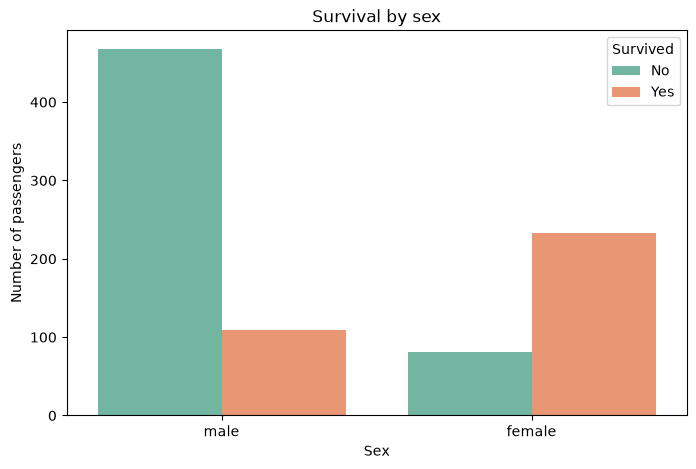

Survival rate by sex:
Sex
female    0.742
male      0.189
Name: Survived, dtype: float64


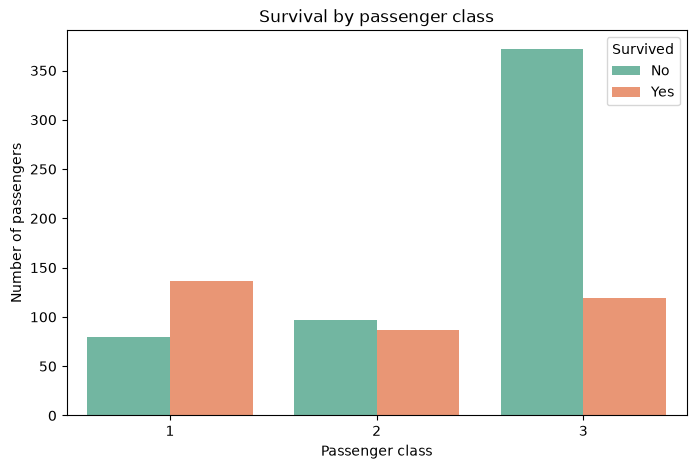


Survival rate by passenger class:
Pclass
1    0.630
2    0.473
3    0.242
Name: Survived, dtype: float64


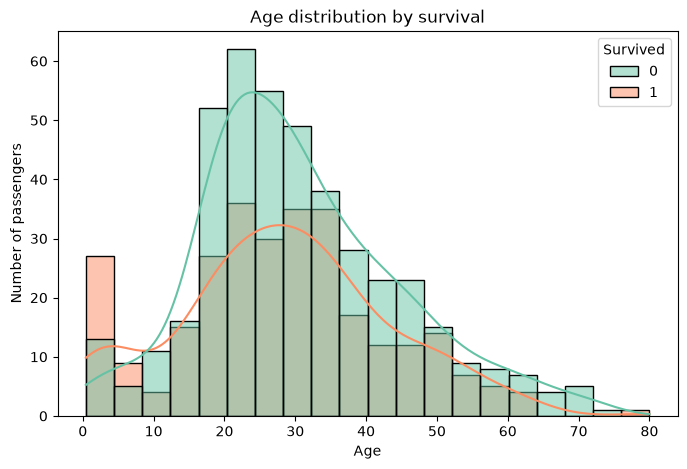

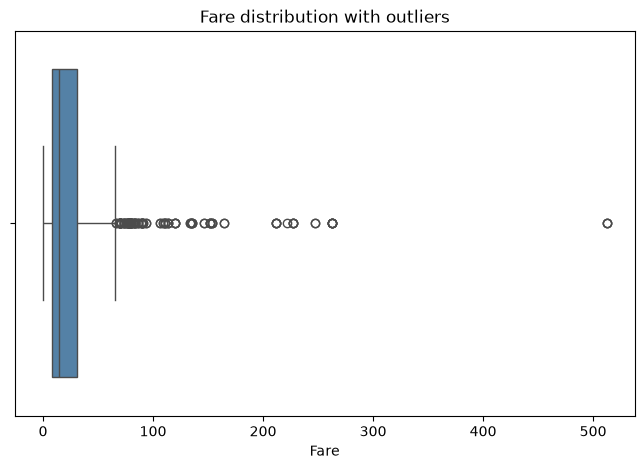


Fare Q1 : 7.9104
Fare Q3 : 31.0
Fare IQR : 23.0896
Fare upper fence : 65.6344
Fares above upper fence : 116
Highest fare : 512.3292


In [2]:
# SECTION 2
# Set the size of the first chart
plt.figure(figsize=(8, 5))

# Count passengers by sex, split by whether they survived
sns.countplot(data=df, x="Sex", hue="Survived", palette="Set2")

# Add labels and title
plt.xlabel("Sex")
plt.ylabel("Number of passengers")
plt.title("Survival by sex")

# Add a legend that names the two groups
plt.legend(title="Survived", labels=["No", "Yes"])

# Save the chart to the charts folder before displaying it
plt.savefig("charts/survival_by_sex.png")

# Show the chart
plt.show()

# Show the share of each sex that survived
print("Survival rate by sex:")
print(df.groupby("Sex")["Survived"].mean().round(3))

# Set the size of the second chart
plt.figure(figsize=(8, 5))

# Count passengers by class, split by whether they survived
sns.countplot(data=df, x="Pclass", hue="Survived", palette="Set2")

# Add labels and title
plt.xlabel("Passenger class")
plt.ylabel("Number of passengers")
plt.title("Survival by passenger class")

# Add a legend that names the two groups
plt.legend(title="Survived", labels=["No", "Yes"])

# Save the chart before displaying it
plt.savefig("charts/survival_by_class.png")

# Show the chart
plt.show()

# Show the share of each class that survived
print("\nSurvival rate by passenger class:")
print(df.groupby("Pclass")["Survived"].mean().round(3))

# Set the size of the third chart
plt.figure(figsize=(8, 5))

# Draw the age distribution, split by whether they survived
sns.histplot(data=df, x="Age", hue="Survived", kde=True, palette="Set2")

# Add labels and title
plt.xlabel("Age")
plt.ylabel("Number of passengers")
plt.title("Age distribution by survival")

# Save the chart before displaying it
plt.savefig("charts/age_by_survival.png")

# Show the chart
plt.show()

# Set the size of the fourth chart
plt.figure(figsize=(8, 5))

# Draw a box plot of fares to show outliers
sns.boxplot(x=df["Fare"], color="steelblue")

# Add label and title
plt.xlabel("Fare")
plt.title("Fare distribution with outliers")

# Save the chart before displaying it
plt.savefig("charts/fare_boxplot.png")

# Show the chart
plt.show()

# Find the first and third quartiles of fare
q1 = np.percentile(df["Fare"], 25)
q3 = np.percentile(df["Fare"], 75)

# Calculate the interquartile range
iqr = q3 - q1

# Calculate the upper fence that marks outliers
upper = q3 + 1.5 * iqr

# Show the outlier figures
print("\nFare Q1 :", q1)
print("Fare Q3 :", q3)
print("Fare IQR :", iqr)
print("Fare upper fence :", upper)
print("Fares above upper fence :", (df["Fare"] > upper).sum())
print("Highest fare :", df["Fare"].max())

In [3]:
# SECTION 3
# Import winsorize to cap extreme values (Data Wrangling lesson)
from scipy.stats.mstats import winsorize

# Find the median age of passengers with a recorded age
age_median = df["Age"].median()

# Fill blank ages with the median age
df["Age"] = df["Age"].fillna(age_median)

# Show the value used
print("Median age used to fill blanks :", age_median)

# Find the most common port of embarkation
embarked_mode = df["Embarked"].value_counts().index[0]

# Fill the blank ports with the most common port
df["Embarked"] = df["Embarked"].fillna(embarked_mode)

# Show the value used
print("Most common port used to fill blanks :", embarked_mode)

# Create a new column: 1 if a cabin number was recorded, 0 if blank
df["HasCabin"] = df["Cabin"].notnull().astype(int)

# Show how many passengers have a cabin recorded
print("\nPassengers with a cabin number :", df["HasCabin"].sum())

# Show the survival rate for each group
print("\nSurvival rate by cabin record:")
print(df.groupby("HasCabin")["Survived"].mean().round(3))

# Remove the original Cabin column, which is 77% blank
df = df.drop(columns=["Cabin"])

# Cap the highest 5% of fares at the 95th percentile value
df["Fare"] = np.array(winsorize(df["Fare"], limits=[0, 0.05]))

# Show the new highest fare
print("\nHighest fare after capping :", df["Fare"].max())

# Confirm no missing values remain
print("\nMissing values after cleaning:")
print(df.isnull().sum())

# Show the shape after cleaning
print("\nShape after cleaning :", df.shape)

Median age used to fill blanks : 28.0
Most common port used to fill blanks : S

Passengers with a cabin number : 204

Survival rate by cabin record:
HasCabin
0    0.300
1    0.667
Name: Survived, dtype: float64

Highest fare after capping : 113.275

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
HasCabin       0
dtype: int64

Shape after cleaning : (891, 12)


In [4]:
# SECTION 4
# Create family size: siblings/spouses + parents/children + the passenger
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1

# Create a flag: 1 if travelling alone, 0 if with family
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)

# Show the survival rate for each group
print("Survival rate by travelling alone:")
print(df.groupby("IsAlone")["Survived"].mean().round(3))

# Pull the title out of each name, e.g. "Braund, Mr. Owen Harris" gives "Mr"
df["Title"] = df["Name"].apply(lambda name: name.split(", ")[1].split(".")[0])

# Show every title found
print("\nTitles found before grouping:")
print(df["Title"].value_counts())


# Define a function that groups each title into one of five categories
def group_title(title):
    # Keep the four common titles as they are
    if title == "Mr" or title == "Mrs" or title == "Miss" or title == "Master":
        return title
    # French and modern forms of Miss
    elif title == "Mlle" or title == "Ms":
        return "Miss"
    # French form of Mrs
    elif title == "Mme":
        return "Mrs"
    # Everything else is rare (Dr, Rev, Col, nobility, and so on)
    else:
        return "Rare"


# Apply the grouping function to every title
df["Title"] = df["Title"].apply(group_title)

# Show the grouped titles
print("\nTitles after grouping:")
print(df["Title"].value_counts())

# Show the survival rate for each title group
print("\nSurvival rate by title:")
print(df.groupby("Title")["Survived"].mean().round(3))

# Encode sex as a number: male 0, female 1
df["Sex"] = df["Sex"].map({"male": 0, "female": 1})

# One-hot encode port and title, dropping the first category of each
df = pd.get_dummies(df, columns=["Embarked", "Title"], drop_first=True, dtype="int")

# Remove columns the model cannot use
df = df.drop(columns=["PassengerId", "Name", "Ticket"])

# Show the final column list
print("\nFinal columns:")
print(df.columns.tolist())

# Show the final shape
print("\nShape after feature engineering :", df.shape)

# Show the first five rows
print("\nFirst five rows:")
print(df.head())

Survival rate by travelling alone:
IsAlone
0    0.506
1    0.304
Name: Survived, dtype: float64

Titles found before grouping:
Title
Mr              517
Miss            182
Mrs             125
Master           40
Dr                7
Rev               6
Major             2
Mlle              2
Col               2
Don               1
Mme               1
Ms                1
Lady              1
Sir               1
Capt              1
the Countess      1
Jonkheer          1
Name: count, dtype: int64

Titles after grouping:
Title
Mr        517
Miss      185
Mrs       126
Master     40
Rare       23
Name: count, dtype: int64

Survival rate by title:
Title
Master    0.575
Miss      0.703
Mr        0.157
Mrs       0.794
Rare      0.348
Name: Survived, dtype: float64

Final columns:
['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'HasCabin', 'FamilySize', 'IsAlone', 'Embarked_Q', 'Embarked_S', 'Title_Miss', 'Title_Mr', 'Title_Mrs', 'Title_Rare']

Shape after feature engineering : (

In [5]:
# SECTION 5
# Import the tool that splits data into training and test sets
from sklearn.model_selection import train_test_split

# Import the tool that runs cross-validation
from sklearn.model_selection import cross_val_score

# Import Pipeline and StandardScaler for the logistic regression model
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Import the three classifiers
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

# Separate the features (X) from the target (y)
X = df.drop(columns=["Survived"])
y = df["Survived"]

# Split 80% for training and 20% for testing, keeping the survival balance in both
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Show the size of each set
print("Training rows :", X_train.shape[0])
print("Test rows :", X_test.shape[0])

# Confirm both sets have about the same survival share
print("\nSurvival share in training set :", round(y_train.mean(), 3))
print("Survival share in test set :", round(y_test.mean(), 3))

# Store the three models in a dictionary, keyed by name
models = {
    # Logistic regression needs scaled features, so it runs inside a pipeline
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("log_reg", LogisticRegression(max_iter=10000, random_state=42))
    ]),
    # Random forest: 100 decision trees that vote
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    # Gradient boosting: trees built one after another, each fixing earlier errors
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

# Run 5-fold cross-validation on each model, then train it on the full training set
print("\n5-fold cross-validation ROC-AUC on the training set:")
for name in models:
    # Get the model from the dictionary
    model = models[name]

    # Score the model on 5 different slices of the training data
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring="roc_auc")

    # Show the average score and how much it varied
    print(name, "mean :", round(scores.mean(), 3))
    print(name, "std :", round(scores.std(), 3))

    # Train the model on the full training set
    model.fit(X_train, y_train)

# Confirm training finished
print("\nAll three models trained on the full training set")

Training rows : 712
Test rows : 179

Survival share in training set : 0.383
Survival share in test set : 0.385

5-fold cross-validation ROC-AUC on the training set:
Logistic Regression mean : 0.869
Logistic Regression std : 0.011


/Users/wyatthockmeyer1/unit5-project/venv/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:219: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights_xp + intercept_xp
/Users/wyatthockmeyer1/unit5-project/venv/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:219: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights_xp + intercept_xp
/Users/wyatthockmeyer1/unit5-project/venv/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:219: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights_xp + intercept_xp
/Users/wyatthockmeyer1/unit5-project/venv/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:356: RuntimeWarning: divide by zero encountered in matmul
  X_grad = X.T @ grad_pointwise
/Users/wyatthockmeyer1/unit5-project/venv/lib/python3.12/site-packages/sklearn/linear_model/_linear_loss.py:356: RuntimeWarning: overflow encountered in matmul
  X_

Random Forest mean : 0.853
Random Forest std : 0.033
Gradient Boosting mean : 0.879
Gradient Boosting std : 0.026

All three models trained on the full training set



Confusion matrix for Logistic Regression
[[97 13]
 [17 52]]

Confusion matrix for Random Forest
[[92 18]
 [19 50]]

Confusion matrix for Gradient Boosting
[[98 12]
 [23 46]]


/Users/wyatthockmeyer1/unit5-project/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/wyatthockmeyer1/unit5-project/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/wyatthockmeyer1/unit5-project/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/wyatthockmeyer1/unit5-project/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/wyatthockmeyer1/unit5-project/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/wyatthockmeyer1/unit5-project/venv/lib/python3.12/site-packages/sklearn/utils/extmath.py:229: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


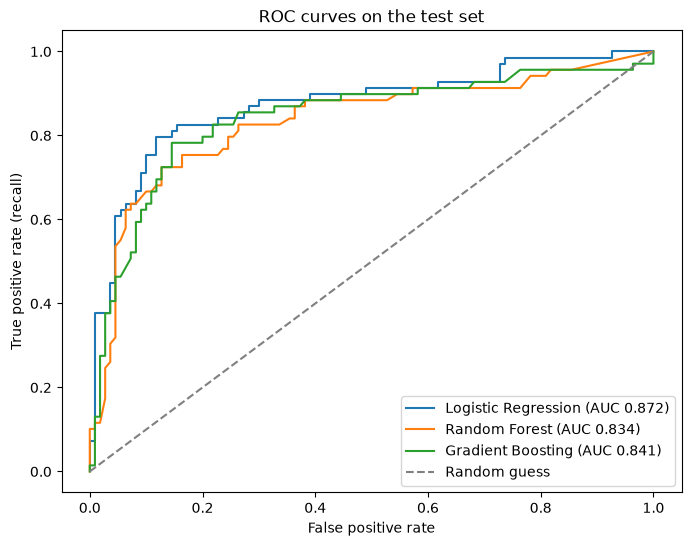


Test set results:
              Model  Accuracy  Precision  Recall    F1  ROC-AUC
Logistic Regression     0.832      0.800   0.754 0.776    0.872
      Random Forest     0.793      0.735   0.725 0.730    0.834
  Gradient Boosting     0.804      0.793   0.667 0.724    0.841


In [6]:
# SECTION 6
# Import the five evaluation metrics, plus ROC curve and confusion matrix tools
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix

# Create an empty list to hold each model's scores
results = []

# Set the size of the ROC curve chart
plt.figure(figsize=(8, 6))

# Score each model on the test set
for name in models:
    # Get the model from the dictionary
    model = models[name]

    # Predict survived (1) or not (0) for each test passenger
    y_pred = model.predict(X_test)

    # Get the predicted probability of survival for each test passenger
    y_prob = model.predict_proba(X_test)[:, 1]

    # Calculate all five metrics and store them in a dictionary
    row = {
        "Model": name,
        "Accuracy": round(accuracy_score(y_test, y_pred), 3),
        "Precision": round(precision_score(y_test, y_pred), 3),
        "Recall": round(recall_score(y_test, y_pred), 3),
        "F1": round(f1_score(y_test, y_pred), 3),
        "ROC-AUC": round(roc_auc_score(y_test, y_prob), 3)
    }

    # Add this model's scores to the results list
    results.append(row)

    # Show the confusion matrix for this model
    print("\nConfusion matrix for", name)
    print(confusion_matrix(y_test, y_pred))

    # Get the points of the ROC curve
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)

    # Draw this model's ROC curve with its AUC in the label
    plt.plot(fpr, tpr, label=name + " (AUC " + str(row["ROC-AUC"]) + ")")

# Draw the diagonal line that a random guess would follow
plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random guess")

# Add labels, title, and legend
plt.xlabel("False positive rate")
plt.ylabel("True positive rate (recall)")
plt.title("ROC curves on the test set")
plt.legend()

# Save the chart before displaying it
plt.savefig("charts/roc_curves.png")

# Show the chart
plt.show()

# Turn the results list into a table
results_df = pd.DataFrame(results)

# Show the comparison table without row numbers
print("\nTest set results:")
print(results_df.to_string(index=False))

## Section 7: Best Model Selection

**Selected model: Logistic Regression** (scaled with StandardScaler in a Pipeline)

| Model | Accuracy | Precision | Recall | F1 | ROC-AUC | CV ROC-AUC (std) |
|---|---|---|---|---|---|---|
| Logistic Regression | 0.832 | 0.800 | 0.754 | 0.776 | 0.872 | 0.869 (0.011) |
| Gradient Boosting | 0.804 | 0.793 | 0.667 | 0.724 | 0.841 | 0.879 (0.026) |
| Random Forest | 0.793 | 0.735 | 0.725 | 0.730 | 0.834 | 0.853 (0.033) |

**Reasoning**

-- Logistic Regression scored highest on all five test metrics.

-- Recall is the priority metric. In the readmission scenario this project is framed around, a missed high-risk case (false negative) costs more than an unnecessary follow-up (false positive). Logistic Regression missed 17 of 69 actual survivors, compared with 19 for Random Forest and 23 for Gradient Boosting.

-- Gradient Boosting led in cross-validation but dropped about 0.04 ROC-AUC on the test set, a sign it fit the training data more closely than it generalizes. Logistic Regression's test ROC-AUC (0.872) closely matched its cross-validation score (0.869), and its low standard deviation (0.011) showed the most consistent performance across folds.

-- Logistic Regression is also the simplest of the three to retrain in the CI/CD pipeline and to explain, since each coefficient shows how a feature raises or lowers the predicted probability.

**Limitations**

-- The test set has only 179 passengers, so differences of a few passengers move the metrics noticeably.

-- Fill values for Age and Embarked and the Fare cap were calculated on all 891 rows before the split. The effect on test scores is negligible but is noted for transparency.

-- Tree-based results can vary slightly between machines (Random Forest differed by one passenger between runs).